<a href="https://colab.research.google.com/github/Keerthanabs1326/Ethnotech_GenAI/blob/main/dream_booth2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q git+https://github.com/huggingface/diffusers
!pip install -q transformers accelerate bitsandbytes safetensors

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.9 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/huggingface/diffusers
%cd diffusers
!pip install -q .

Cloning into 'diffusers'...
remote: Enumerating objects: 119858, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 119858 (delta 142), reused 70 (delta 66), pack-reused 119633 (from 3)
Receiving objects: 100% (119858/119858), 94.96 MiB | 16.51 MiB/s, done.
Resolving deltas: 100% (89831/89831), done.
/content/diffusers
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gemini_Generated_Image_rthkftrthkftrthk6.png to Gemini_Generated_Image_rthkftrthkftrthk6.png
Saving Gemini_Generated_Image_rthkftrthkftrthk4.png to Gemini_Generated_Image_rthkftrthkftrthk4.png
Saving Gemini_Generated_Image_rthkftrthkftrthk3.png to Gemini_Generated_Image_rthkftrthkftrthk3.png
Saving Gemini_Generated_Image_vkbalyvkbalyvkba2.png to Gemini_Generated_Image_vkbalyvkbalyvkba2.png
Saving Gemini_Generated_Image_vkbalyvkbalyvkba1.png to Gemini_Generated_Image_vkbalyvkbalyvkba1.png
Saving Gemini_Generated_Image_vkbalyvkbalyvkba.png to Gemini_Generated_Image_vkbalyvkbalyvkba.png


In [ ]:
import os
os.makedirs("/content/training_images", exist_ok=True)
for file in uploaded.keys():
    os.rename(file, f"/content/training_images/{file}")
print("Training images ready!")

Training images ready!


In [ ]:
MODEL_NAME = "runwayml/stable-diffusion-v1-5"
OUTPUT_DIR = "/content/dreambooth-trained"
INSTANCE_PROMPT = "a photo of sks person"

In [ ]:
!accelerate launch examples/dreambooth/train_dreambooth.py \
  --pretrained_model_name_or_path=$MODEL_NAME \
  --instance_data_dir="/content/training_images" \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="$INSTANCE_PROMPT" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --mixed_precision="fp16" \
  --use_8bit_adam

print("DreamBooth training complete!")

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
tokenizer_config.json: 100% 806/806 [00:00<00:00, 3.17MB/s]
vocab.json: 1.06MB [00:00, 28.3MB/s]
merges.txt: 525kB [00:00, 46.4MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 1.82MB/s]
config.json: 100% 617/617 [00:00<00:00, 2.40MB/s]
You are using a model of type clip_text_model to instantiate a model of ty

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

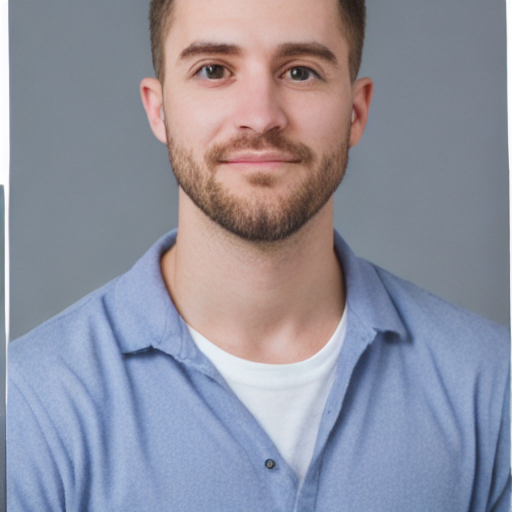

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "/content/dreambooth-trained",
    torch_dtype=torch.float16,
).to("cuda")

prompt = "a professional studio portrait of sks person, ultra realistic"

image = pipe(prompt).images[0]
image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

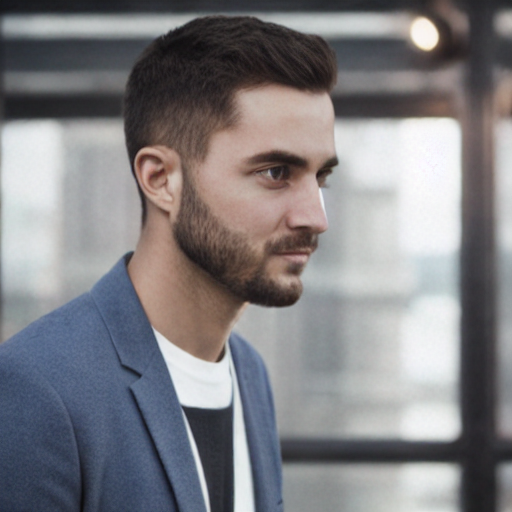

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "/content/dreambooth-trained",
    torch_dtype=torch.float16,
).to("cuda")

prompt = "a cinematic portrait photo of sks person, ultra realistic, studio lighting"

image = pipe(prompt).images[0]
image
